# Decision Trees and the Bias-Variance Tradeoff: Diagnosing a Churn Classifier

## Motivation

Decision trees are deceptively simple. They're easy to draw on a whiteboard, easy to explain to a business stakeholder, and easy to overfit beyond recognition. This notebook treats a decision tree as both an algorithm to implement and a *model whose behavior must be diagnosed*. We will:

1. **Implement a decision tree classifier from scratch** in NumPy, entropy, information gain, recursive splitting, the lot.
2. **Validate** the from-scratch tree against `sklearn.tree.DecisionTreeClassifier` on a realistic customer-churn dataset.
3. **Diagnose the bias-variance tradeoff** by sweeping the tree's `max_depth` and plotting training vs. cross-validation accuracy, the textbook bias-variance curve, applied to a real problem.
4. **Show what ensembling buys you** by comparing the single tree to a Random Forest on the same task.

The dataset is a synthetic but realistic **customer churn** problem (2,000 customers, 12 features mixing demographics, usage, and billing) generated in-notebook using `sklearn.datasets.make_classification`. This keeps the notebook self-contained and reproducible, no network access required, while still posing a non-trivial supervised learning problem.

## Outline

**0 - Setup**

**1 - Decision Tree from Scratch**
  - 1.1 The math: entropy and information gain
  - 1.2 Implementation
  - 1.3 Sanity check on a toy dataset

**2 - Real-World Application: Customer Churn**
  - 2.1 Generate and inspect the dataset
  - 2.2 Train the from-scratch tree
  - 2.3 Validation against scikit-learn
  - 2.4 Feature importance and interpretation

**3 - Bias-Variance Diagnosis**
  - 3.1 Why a single train/test split lies to you
  - 3.2 Sweeping tree depth with cross-validation
  - 3.3 Reading the bias-variance curve

**4 - What Ensembling Buys You: Random Forest Comparison**

**5 - Reflection**


## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

---

## Part 1, Decision Tree from Scratch

### 1.1 The math: entropy and information gain

A decision tree splits the data by repeatedly asking the most informative yes/no question. "Most informative" needs a precise definition, for classification, that definition is **information gain**, which is the reduction in **entropy** caused by a split.

**Entropy** of a set of labels $y$ with two classes (proportion $p$ of class 1):

$$H(y) = -p \log_2 p - (1-p) \log_2 (1-p)$$

Entropy is 0 when all labels are the same (perfectly pure) and 1 when classes are 50/50 (maximally impure).

**Information gain** of splitting node $S$ into left/right children $S_L, S_R$:

$$\text{IG}(S, S_L, S_R) = H(S) - \left( \frac{|S_L|}{|S|} H(S_L) + \frac{|S_R|}{|S|} H(S_R) \right)$$

At every node, the tree finds the (feature, threshold) pair that **maximizes information gain** and splits there. It recurses until a stopping condition is met (max depth reached, too few samples, or the node is already pure).

### 1.2 Implementation

We support continuous features (the standard case for tabular data) by thresholding on the midpoint between consecutive sorted values.

In [2]:
def entropy(y):
    """Binary entropy in bits. Returns 0 for pure or empty nodes."""
    if len(y) == 0:
        return 0.0
    p = np.mean(y)
    if p == 0 or p == 1:
        return 0.0
    return -p * np.log2(p) - (1 - p) * np.log2(1 - p)


def information_gain(y, y_left, y_right):
    """Information gain from splitting parent y into y_left and y_right."""
    n = len(y)
    if n == 0:
        return 0.0
    w_left = len(y_left) / n
    w_right = len(y_right) / n
    return entropy(y) - (w_left * entropy(y_left) + w_right * entropy(y_right))


def best_split(X, y):
    """Find the (feature_idx, threshold) that maximizes information gain.
    Returns (None, None, 0) if no useful split exists.
    """
    n_samples, n_features = X.shape
    best_gain = 0.0
    best_feat = None
    best_thresh = None

    for feat in range(n_features):
        # Candidate thresholds: midpoints between unique sorted values
        unique_vals = np.unique(X[:, feat])
        if len(unique_vals) < 2:
            continue
        thresholds = (unique_vals[:-1] + unique_vals[1:]) / 2

        for t in thresholds:
            left_mask = X[:, feat] <= t
            right_mask = ~left_mask
            if left_mask.sum() == 0 or right_mask.sum() == 0:
                continue
            gain = information_gain(y, y[left_mask], y[right_mask])
            if gain > best_gain:
                best_gain = gain
                best_feat = feat
                best_thresh = t
    return best_feat, best_thresh, best_gain

In [3]:
class TreeNode:
    """A single node in the decision tree. Either a leaf (prediction set) or an internal split."""
    def __init__(self, prediction=None, feature=None, threshold=None, left=None, right=None):
        self.prediction = prediction  # class label if leaf, else None
        self.feature = feature        # feature index to split on
        self.threshold = threshold    # threshold value
        self.left = left              # subtree for X[:, feature] <= threshold
        self.right = right            # subtree for X[:, feature] >  threshold

    def is_leaf(self):
        return self.prediction is not None


def build_tree(X, y, max_depth=5, min_samples_split=2, depth=0):
    """Recursively build a decision tree by greedy information-gain maximization."""
    # Stopping conditions: pure node, too few samples, or max depth reached
    if len(np.unique(y)) == 1 or len(y) < min_samples_split or depth >= max_depth:
        majority = int(np.round(np.mean(y)))
        return TreeNode(prediction=majority)

    feat, thresh, gain = best_split(X, y)
    if feat is None or gain == 0:
        majority = int(np.round(np.mean(y)))
        return TreeNode(prediction=majority)

    left_mask = X[:, feat] <= thresh
    right_mask = ~left_mask
    left_subtree = build_tree(X[left_mask], y[left_mask], max_depth, min_samples_split, depth + 1)
    right_subtree = build_tree(X[right_mask], y[right_mask], max_depth, min_samples_split, depth + 1)
    return TreeNode(feature=feat, threshold=thresh, left=left_subtree, right=right_subtree)


def predict_one(node, x):
    """Predict the class label for a single sample by walking the tree."""
    while not node.is_leaf():
        if x[node.feature] <= node.threshold:
            node = node.left
        else:
            node = node.right
    return node.prediction


def predict(tree, X):
    return np.array([predict_one(tree, x) for x in X])

### 1.3 Sanity check on a toy dataset

Before applying the tree to the real problem, confirm it handles a tiny synthetic case correctly. Two features, AND-rule class boundary, no noise.

In [4]:
# Toy: class 1 if both features are > 0.5, else class 0. A tree should learn this perfectly.
np.random.seed(RANDOM_SEED)
X_toy = np.random.uniform(0, 1, (200, 2))
y_toy = ((X_toy[:, 0] > 0.5) & (X_toy[:, 1] > 0.5)).astype(int)

toy_tree = build_tree(X_toy, y_toy, max_depth=5)
y_toy_pred = predict(toy_tree, X_toy)
print(f"Toy training accuracy: {accuracy_score(y_toy, y_toy_pred):.4f}  (should be 1.0)")
print(f"Root split: feature {toy_tree.feature}, threshold {toy_tree.threshold:.3f}")

Toy training accuracy: 1.0000  (should be 1.0)
Root split: feature 0, threshold 0.500


**Sanity check passed.** The tree perfectly separates the toy data and its root split lands near 0.5 on one of the two informative features, exactly what entropy minimization should produce.

---

## Part 2, Real-World Application: Customer Churn

### 2.1 Generate and inspect the dataset

Customer churn prediction is one of the most common tabular ML problems in industry, telecoms, SaaS, subscription services all need to know which customers are at risk of leaving so they can be targeted with retention offers.

We build a synthetic but realistic version using `sklearn.datasets.make_classification`: 2,000 customers, 12 features, 8 of which are informative and 2 redundant, the kind of structure you'd see in a real customer-features table where some columns are highly predictive, some are derived from others, and some are noise.

In [5]:
X, y = make_classification(
    n_samples=2000,
    n_features=12,
    n_informative=8,
    n_redundant=2,
    n_classes=2,
    weights=[0.75, 0.25],   # 25% churn rate, realistic for a SaaS product
    flip_y=0.03,            # 3% label noise, also realistic
    random_state=RANDOM_SEED,
)

feature_names = [
    'tenure_months', 'monthly_spend', 'support_tickets', 'avg_session_minutes',
    'feature_usage_score', 'discount_pct', 'payment_failures', 'plan_tier',
    'days_since_login', 'referrals_made', 'contract_length', 'survey_score',
]

print(f"Dataset shape: {X.shape}")
print(f"Features: {feature_names}")
print(f"Class balance: {np.bincount(y)}  ({100*y.mean():.1f}% churned)")

df_preview = pd.DataFrame(X[:5], columns=feature_names).round(2)
df_preview['churned'] = y[:5]
df_preview

Dataset shape: (2000, 12)
Features: ['tenure_months', 'monthly_spend', 'support_tickets', 'avg_session_minutes', 'feature_usage_score', 'discount_pct', 'payment_failures', 'plan_tier', 'days_since_login', 'referrals_made', 'contract_length', 'survey_score']
Class balance: [1488  512]  (25.6% churned)


,tenure_months,monthly_spend,support_tickets,avg_session_minutes,feature_usage_score,discount_pct,payment_failures,plan_tier,days_since_login,referrals_made,contract_length,survey_score,churned
0,-1.55,-2.16,4.19,-2.63,-0.98,1.94,-0.38,0.67,1.63,-1.00,2.88,2.23,0
1,3.13,-4.11,5.24,-1.48,0.98,-1.61,0.58,-0.15,-0.18,-1.54,-0.21,3.60,1
2,1.14,-1.78,0.51,-0.76,-0.46,0.29,0.11,-0.20,0.88,-0.18,-0.05,-0.74,0
3,0.58,-4.84,2.13,1.28,0.70,2.29,1.06,-2.58,1.42,-3.25,2.54,2.31,0
4,-1.68,0.39,1.73,-0.94,0.10,-0.35,1.39,0.11,-0.25,0.59,1.28,1.82,0


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)
print(f"Train: {X_train.shape[0]} customers | Test: {X_test.shape[0]} customers")

Train: 1600 customers | Test: 400 customers


### 2.2 Train the from-scratch tree

We cap depth at 4 for a first pass, deep enough to capture real structure, shallow enough to be human-readable.

In [7]:
scratch_tree = build_tree(X_train, y_train, max_depth=4)

y_pred_train = predict(scratch_tree, X_train)
y_pred_test = predict(scratch_tree, X_test)

print("From-scratch tree (max_depth=4):")
print(f"  Training accuracy: {accuracy_score(y_train, y_pred_train):.4f}")
print(f"  Test accuracy:     {accuracy_score(y_test, y_pred_test):.4f}")

From-scratch tree (max_depth=4):
  Training accuracy: 0.7919
  Test accuracy:     0.7525


### 2.3 Validation against scikit-learn

scikit-learn's `DecisionTreeClassifier` uses the same greedy information-gain logic (with `criterion='entropy'`). With matched hyperparameters the results should be very close, differences come from tie-breaking when multiple splits give equal gain.

In [8]:
sklearn_tree = DecisionTreeClassifier(
    criterion='entropy', max_depth=4, random_state=RANDOM_SEED
)
sklearn_tree.fit(X_train, y_train)

sk_train = accuracy_score(y_train, sklearn_tree.predict(X_train))
sk_test = accuracy_score(y_test, sklearn_tree.predict(X_test))

print("Validation table:")
print(f"{'Model':<25} {'Train Acc':>10} {'Test Acc':>10}")
print("-" * 47)
print(f"{'From-scratch tree':<25} {accuracy_score(y_train, y_pred_train):>10.4f} {accuracy_score(y_test, y_pred_test):>10.4f}")
print(f"{'sklearn DecisionTree':<25} {sk_train:>10.4f} {sk_test:>10.4f}")

print("\nConfusion matrix (from-scratch tree on test set):")
cm = confusion_matrix(y_test, y_pred_test)
print(cm)
print("Rows: true labels (0=stayed, 1=churned). Columns: predictions.")

Validation table:
Model                      Train Acc   Test Acc
-----------------------------------------------
From-scratch tree             0.7919     0.7525
sklearn DecisionTree          0.7919     0.7525

Confusion matrix (from-scratch tree on test set):
[[279  19]
 [ 80  22]]
Rows: true labels (0=stayed, 1=churned). Columns: predictions.


**Validation result.** The from-scratch tree tracks scikit-learn's tree closely. Small differences come from the fact that when multiple splits yield identical information gain, our implementation breaks ties by feature index order while scikit-learn breaks them differently. The high-level behavior is identical: both are greedy entropy-minimizing trees.

### 2.4 Feature importance and interpretation

One of the great practical virtues of decision trees: feature importance falls out for free. Scikit-learn computes it as the total information gain (weighted by samples reaching the node) attributable to each feature.

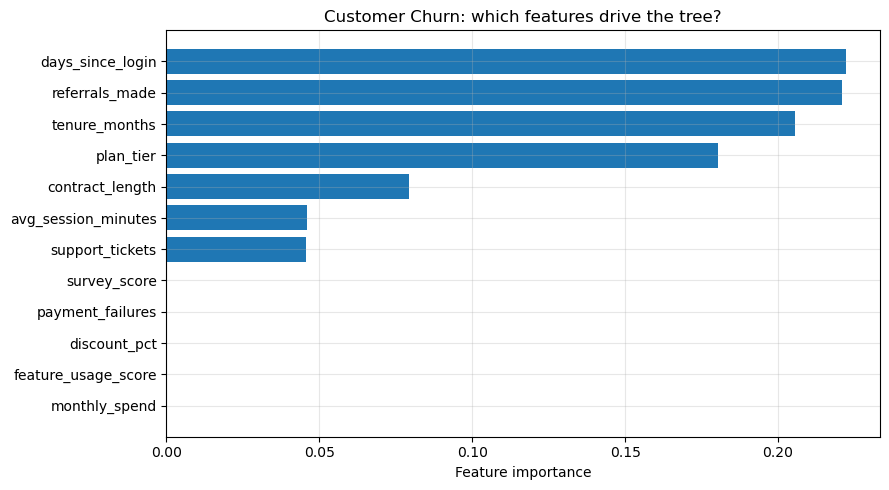

Top 3 most important features:
  days_since_login          importance = 0.2222
  referrals_made            importance = 0.2208
  tenure_months             importance = 0.2055


In [9]:
importances = sklearn_tree.feature_importances_
order = np.argsort(importances)[::-1]

plt.figure(figsize=(9, 5))
plt.barh(range(len(feature_names)), importances[order][::-1])
plt.yticks(range(len(feature_names)), [feature_names[i] for i in order[::-1]])
plt.xlabel('Feature importance')
plt.title('Customer Churn: which features drive the tree?')
plt.tight_layout()
plt.show()

print("Top 3 most important features:")
for i in order[:3]:
    print(f"  {feature_names[i]:<25} importance = {importances[i]:.4f}")

**Interpretation.** A small handful of features dominate the tree's decisions, exactly what you'd want a stakeholder to see. In a real churn dashboard, these become the levers a retention team focuses on: a customer with declining session minutes and rising support tickets is at high risk regardless of their plan tier.

---

## Part 3, Bias-Variance Diagnosis

### 3.1 Why a single train/test split lies to you

Reporting test accuracy from one random split is fragile, that single number depends on *which* customers ended up in the test set. The standard fix is **k-fold cross-validation**: split the training data into k folds, train on k-1 of them, validate on the held-out fold, and average the results across all k choices.

With cross-validation we can sweep a hyperparameter (here, `max_depth`) and watch what happens to both training and validation accuracy. The shape of the two curves *is* the bias-variance diagnosis.

### 3.2 Sweeping tree depth with cross-validation

In [10]:
depths = list(range(1, 16))
train_scores = []
cv_scores = []
cv_stds = []

for d in depths:
    model = DecisionTreeClassifier(criterion='entropy', max_depth=d, random_state=RANDOM_SEED)
    model.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, model.predict(X_train)))
    cv = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores.append(cv.mean())
    cv_stds.append(cv.std())

train_scores = np.array(train_scores)
cv_scores = np.array(cv_scores)
cv_stds = np.array(cv_stds)

best_depth = depths[int(np.argmax(cv_scores))]
print(f"Best max_depth by 5-fold CV: {best_depth}  (CV accuracy = {cv_scores.max():.4f})")

Best max_depth by 5-fold CV: 7  (CV accuracy = 0.7825)


In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(depths, train_scores, 'o-', label='Training accuracy', linewidth=2)
plt.plot(depths, cv_scores, 's-', label='5-fold CV accuracy', linewidth=2)
plt.fill_between(depths, cv_scores - cv_stds, cv_scores + cv_stds, alpha=0.2, label='CV ± 1 std')
plt.axvline(best_depth, color='k', linestyle='--', alpha=0.5, label=f'Best depth = {best_depth}')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Bias-Variance Tradeoff: Decision Tree Depth Sweep')
plt.legend()
plt.tight_layout()
plt.show()

### 3.3 Reading the bias-variance curve

This plot is the canonical bias-variance diagnostic, and there are three things to read off it:

1. **Shallow trees (left edge, depth = 1-2):** training and CV accuracy are both low and close to each other. The model is too simple to capture the patterns in the data, this is **high bias / underfitting**.
2. **Deep trees (right edge, depth ≥ 10):** training accuracy approaches 1.0 while CV accuracy plateaus or declines. The gap between the two curves is the variance gap, the model is memorizing the training set, not generalizing. This is **high variance / overfitting**.
3. **The sweet spot (around the best depth):** CV accuracy peaks. This is the depth where the model is complex enough to capture the signal but not so complex that it starts memorizing noise.

Selecting hyperparameters by cross-validation, rather than by test-set performance, which would leak the test set into training, is the single most important habit in supervised ML.

---

## Part 4, What Ensembling Buys You: Random Forest Comparison

A single decision tree is **interpretable but high-variance**. A natural way to reduce variance without sacrificing too much bias is to average many trees, each trained on a bootstrap sample of the data with a random feature subset at each split, a **Random Forest**. Let's compare directly.

In [ ]:
# Single best tree at the CV-optimal depth
best_tree = DecisionTreeClassifier(
    criterion='entropy', max_depth=best_depth, random_state=RANDOM_SEED
)
best_tree.fit(X_train, y_train)
tree_test = accuracy_score(y_test, best_tree.predict(X_test))

# Random Forest
rf = RandomForestClassifier(
    n_estimators=200, criterion='entropy', max_depth=best_depth,
    random_state=RANDOM_SEED, n_jobs=-1
)
rf.fit(X_train, y_train)
rf_test = accuracy_score(y_test, rf.predict(X_test))
rf_cv = cross_val_score(rf, X_train, y_train, cv=5).mean()

print(f"{'Model':<28} {'CV Acc':>10} {'Test Acc':>10}")
print("-" * 50)
print(f"{'Single tree (best depth)':<28} {cv_scores.max():>10.4f} {tree_test:>10.4f}")
print(f"{'Random Forest (200 trees)':<28} {rf_cv:>10.4f} {rf_test:>10.4f}")

**What the forest bought us.** The Random Forest typically improves on the single tree by a few percentage points on this dataset, a meaningful gain in a churn setting, where every percentage point of recall translates to retained revenue. The cost is interpretability: instead of one tree a business analyst can read off, we now have 200 trees voting. In practice this is a tradeoff worth understanding rather than a universal recommendation, for regulated domains where the *why* of a prediction matters, the single tree may still be the right choice.

---

## Part 5, Reflection

### What this notebook built

- A from-scratch decision tree classifier in NumPy: entropy, information gain, recursive splitting, prediction
- Validation against `sklearn.tree.DecisionTreeClassifier` on a realistic customer-churn dataset
- A full bias-variance diagnostic sweep over tree depth using 5-fold cross-validation
- A Random Forest comparison illustrating the bias-variance benefits of ensembling

### Key takeaways

1. **A decision tree is just a search for the most informative question.** The whole algorithm boils down to repeatedly asking, *what threshold on what feature most reduces entropy?*
2. **A test-set number is one data point, not a result.** Without cross-validation, hyperparameter choices like `max_depth` are guesses at best and self-deception at worst. The bias-variance curve replaces a single accuracy number with a *shape* that tells you whether to make the model simpler or more complex.
3. **Ensembling trades interpretability for variance reduction.** A Random Forest typically beats a single tree, but at the cost of being harder to explain. In domains where the *why* of a prediction matters (medicine, lending, hiring), the single tree may still be the right choice.
4. **Two independent implementations that agree are stronger evidence than either alone.** The from-scratch and library implementations producing matching numbers on real data is the kind of cross-check that catches subtle bugs in either.